In [2]:
 # 1.Incarcarea si normalizarea setului de date
import tensorflow as tf
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Dimensiune x_train:", x_train.shape)
print("Dimensiune y_train:", y_train.shape)

print("Dimensiune x_test:", x_test.shape)
print("Dimensiune y_test:", y_test.shape)

x_train = x_train / 255.0
x_test = x_test / 255.0

print("Valoare minima:", x_train.min())
print("Valoare maxima:", x_train.max())

Dimensiune x_train: (60000, 28, 28)
Dimensiune y_train: (60000,)
Dimensiune x_test: (10000, 28, 28)
Dimensiune y_test: (10000,)
Valoare minima: 0.0
Valoare maxima: 1.0


In [3]:
 # 2. Model Sequential
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from keras import Input

model = Sequential([
    Input((28,28)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
 # 3.Antrenara modelului

model.compile(optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'])
model.fit(x_train, y_train, epochs=5)
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Loss pe setul de test:", test_loss)
print("Acuratete pe setul de test:", test_accuracy)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9884 - loss: 0.0385
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9923 - loss: 0.0264
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9929 - loss: 0.0230
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9947 - loss: 0.0180
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9954 - loss: 0.0148
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9787 - loss: 0.0826
Loss pe setul de test: 0.08264756947755814
Acuratete pe setul de test: 0.9786999821662903


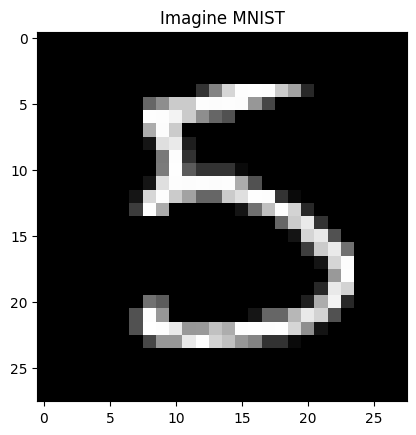

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
Predictia modelului este: 5
Cifra reala este: 5


In [10]:
import numpy as np
import matplotlib.pyplot as plt

index = 15

plt.imshow(x_test[index], cmap='gray')
plt.title("Imagine MNIST")
plt.show()


prediction = model.predict(np.array([x_test[index]]))

print("Predictia modelului este:", np.argmax(prediction))

print("Cifra reala este:", y_test[index])

In [11]:
 # 5.Modificarea numarului de neuroni

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from keras import Input

model = Sequential([
    Input((28,28)),
    Flatten(),
    Dense(512, activation='relu'),
    Dense(10, activation='softmax')
])
model.compile(optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'])
model.fit(x_train, y_train, epochs=5)
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Loss pe setul de test:", test_loss)
print("Acuratete pe setul de test:", test_accuracy)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 57s 18ms/step - accuracy: 0.9417 - loss: 0.2007
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - accuracy: 0.9757 - loss: 0.0805
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.9844 - loss: 0.0516
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9883 - loss: 0.0353
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.9907 - loss: 0.0277
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9806 - loss: 0.0677
Loss pe setul de test: 0.06766663491725922
Acuratete pe setul de test: 0.9805999994277954


In [12]:
 # 6.Schimbare numar epoci

model.fit(x_train, y_train, epochs=3)
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Loss pe setul de test:", test_loss)
print("Acuratete pe setul de test:", test_accuracy)

Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9936 - loss: 0.0200
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - accuracy: 0.9939 - loss: 0.0183
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9951 - loss: 0.0154
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9819 - loss: 0.0774
Loss pe setul de test: 0.07740050554275513
Acuratete pe setul de test: 0.9818999767303467


In [13]:
 # 7. Functia de activare tanh

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from keras import Input

model = Sequential([
    Input((28,28)),
    Flatten(),
    Dense(512, activation='tanh'),
    Dense(10, activation='softmax')
])
model.compile(optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'])
model.fit(x_train, y_train, epochs=5)
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Loss pe setul de test:", test_loss)
print("Acuratete pe setul de test:", test_accuracy)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - accuracy: 0.9190 - loss: 0.2744
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9630 - loss: 0.1243
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - accuracy: 0.9752 - loss: 0.0787
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 36s 10ms/step - accuracy: 0.9829 - loss: 0.0540
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - accuracy: 0.9879 - loss: 0.0387
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9771 - loss: 0.0725
Loss pe setul de test: 0.07245320826768875
Acuratete pe setul de test: 0.9771000146865845


In [14]:
# 8. Inlocuire set de date
from tensorflow.keras.datasets import fashion_mnist

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

model = Sequential([
    Input((28,28)),
    Flatten(),
    Dense(128, activation='tanh'),
    Dense(10, activation='softmax')
])
model.compile(optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'])
model.fit(x_train, y_train, epochs=5)
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Loss pe setul de test:", test_loss)
print("Acuratete pe setul de test:", test_accuracy)


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 9s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 12ms/step - accuracy: 0.8271 - loss: 0.4818
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8647 - loss: 0.3723
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - accuracy: 0.8772 - loss: 0.3364
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8844 - loss: 0.3139
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - accuracy: 0.8915 - loss: 0.2964
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8745 - loss: 0.3475
Loss pe setul de test: 0.34753796458244324
Acuratete pe setul de test: 0.8744999766349792
